# Figure 2;

- TODO: Ancestry 
- Genetic Variations
    - A: Repeat Elements
    - B: Structural Variants
    - C: Small Variants


In [7]:
suppressPackageStartupMessages(library(tidyverse))
suppressMessages(source("../scripts/00_R_presets.R"))
options(repr.plot.width = 8, repr.plot.height = 4)

var_fig_dir <- "../../doc/figures/variant_plots"
fig_dir <- "../../doc/figures"


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


In [8]:
sample_metadata <- read_tsv("../../doc/tables/samples_metadata.tsv") %>%
    rowwise() %>%
    mutate(superpop = assign_superpop(birth_country)) %>%
    ungroup()

head(sample_metadata)

Rows: 33 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (8): t2t_identifier, ge-health_identifier, gender, sample_type, birth_co...
dbl (2): birth_year, age

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


t2t_identifier,ge-health_identifier,gender,birth_year,sample_type,birth_country,birth_country_parents,birth_country_grandparents,birth_location,age,superpop
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
T2T00,Ge-Health 001,Male,1959,Blood,Germany,NA,NA,NA,65,EUR
T2T00_1,Ge-Health 322,Male,1930,Blood,Germany,NA,NA,NA,95,EUR
T2T00_2,Ge-Health 323,Female,1934,Blood,Germany,NA,NA,NA,91,EUR
T2T01,GE-Health 327,Female,1988,Blood,NA,Fraternal: Germany,NA,NA,37,EUR
T2T02,GE-Health 326,Male,1989,Blood,Austria,NA,NA,NA,36,EUR
T2T03,GE-Health 324,Female,1990,Blood,Spain,NA,NA,NA,35,EUR


## Part A: Repetitive Elements

In [9]:
# Load RepeatMasker data
rm_data <- read_csv("../../doc/tables/for_plots/repeatmasker_summary.all_samples.csv", show_col_types = FALSE)

# Create sample groups
rm_data <- rm_data %>%
    left_join(sample_metadata %>% 
        select(t2t_identifier, superpop, age, gender),
        by = c("sample" = "t2t_identifier"))

head(rm_data)

sample,repeat_class,repeat_family,count,total_length,mean_length,mean_div,superpop,age,gender
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
T2T00,DNA,Crypton,576,84401,146.5295,25.40868,EUR,65,Male
T2T00,DNA,Crypton-A,269,39008,145.0112,26.81933,EUR,65,Male
T2T00,DNA,Kolobok,720,118747,164.9264,24.98278,EUR,65,Male
T2T00,DNA,MULE-MuDR,5917,1944303,328.5961,18.14195,EUR,65,Male
T2T00,DNA,Merlin,441,75869,172.0385,21.29002,EUR,65,Male
T2T00,DNA,PIF-Harbinger,730,128138,175.5315,26.64685,EUR,65,Male


In [10]:
# Calculate genome percentages by repeat class
class_data <- rm_data %>%
    group_by(sample, repeat_class, age, gender, superpop) %>%
    summarise(class_total = sum(total_length), .groups = "drop_last") %>%
    group_by(sample) %>%
    mutate(
        total_genome = sum(class_total),
        percentage = (class_total / total_genome) * 100
    ) %>%
    ungroup()

# Check the data
class_data %>% arrange(desc(percentage)) %>% head(10)

sample,repeat_class,age,gender,superpop,class_total,total_genome,percentage
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
T2T16,LINE,45,Female,EUR,1256880477,3241055821,38.77997
T2T10,LINE,31,Female,EUR,1276138976,3302398054,38.64280
T2T01,LINE,37,Female,EUR,1253582620,3248475359,38.58988
T2T12,LINE,36,Female,EUR,1250842093,3244358666,38.55437
T2T15,LINE,25,Female,EUR,1253267888,3250695801,38.55383
T2T08,LINE,37,Female,SAS,1253429493,3255254398,38.50481
T2T13,LINE,29,Female,EAS,1258433338,3269104607,38.49474
T2T07,LINE,39,Female,AMR,1258899897,3278681296,38.39653
T2T00_2,LINE,91,Female,EUR,1283225275,3344039158,38.37351


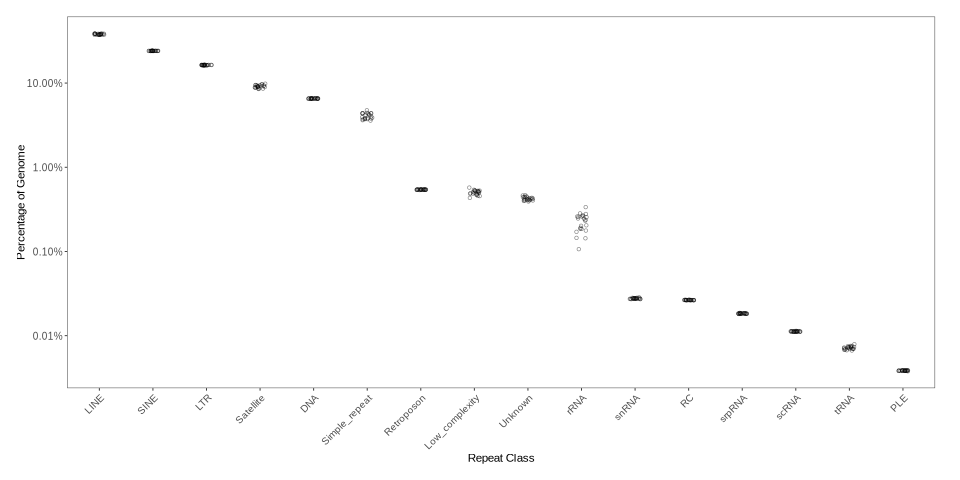

In [11]:
# Figure 2D: Repetitive Element Variation
fig2d_repeats <- ggplot(class_data, aes(x = fct_reorder(repeat_class, class_total, sum, .desc = TRUE), 
                                        y = percentage)) +
    #geom_violin(alpha = 0.7, position = position_dodge(width = 0.8)) +
    #geom_boxplot(width = 0.1, position = position_dodge(width = 0.8), 
    #             outlier.shape = NA, alpha = 0.8) +
    geom_jitter(width = 0.1, alpha = 0.5, shape = 21) +
    scale_y_log10(labels = scales::percent_format(scale = 1)) +
    labs(
        x = "Repeat Class",
        y = "Percentage of Genome"
    ) +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom"
    )

fig2d_repeats
ggsave(file.path(fig_dir, "fig2_repeat_elements.png"), fig2d_repeats, width = 3.5, height = 2.2, dpi = 300)
ggsave(file.path(fig_dir, "fig2_repeat_elements.pdf"), fig2d_repeats, width = 3.5, height = 2.2, dpi = 300)


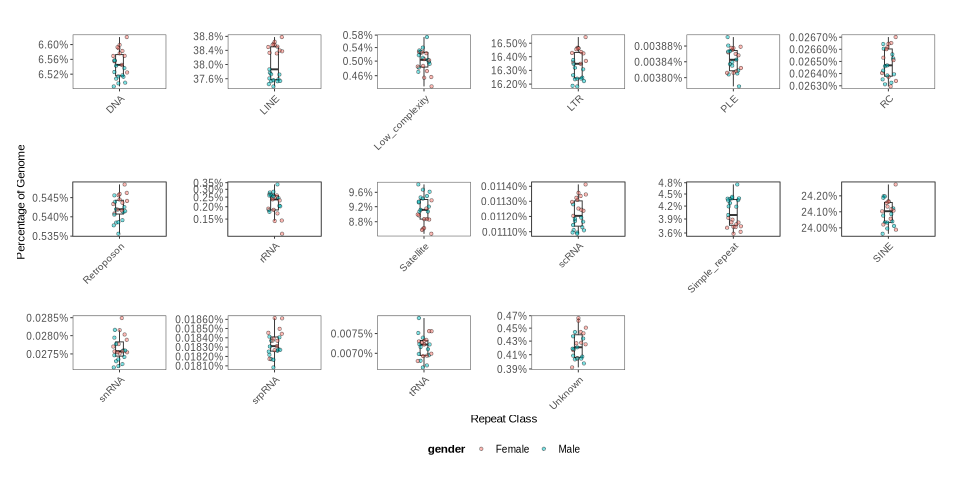

In [12]:
# Figure 2D: Repetitive Element Variation
fig2d_repeats_facet <- ggplot(class_data, aes(x = fct_reorder(repeat_class, class_total, sum, .desc = TRUE), 
                                        y = percentage)) +
    #geom_violin(alpha = 0.7, position = position_dodge(width = 0.8)) +
    geom_boxplot(width = 0.1, position = position_dodge(width = 0.8), 
                 outlier.shape = NA, alpha = 0.8) +
    geom_jitter(aes(fill = gender), width = 0.1, alpha = 0.5, shape = 21) +
    scale_y_log10(labels = scales::percent_format(scale = 1)) +
    labs(
        x = "Repeat Class",
        y = "Percentage of Genome"
    ) +
    facet_wrap(~repeat_class, nrow = 3, scales = "free", labeller = function(x) "") +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom"
    )

fig2d_repeats_facet
ggsave(file.path(fig_dir, "fig2_repeat_elements_facet.png"), fig2d_repeats_facet, width = 7, height = 5, dpi = 300)
ggsave(file.path(fig_dir, "fig2_repeat_elements_facet.pdf"), fig2d_repeats_facet, width = 7, height = 5, dpi = 300)

## B: Structural Variant Analysis

Analysis of structural variants (SVs) from hapdiff including:
- SV type distribution (DEL, INS, INV, DUP)
- SV size distribution
- Zygosity and phasing statistics
- Per-chromosome distribution

In [13]:
# Load SV statistics data (combining all_samples and HPRC)
sv_details_t2t <- read_tsv("../../doc/tables/for_plots/sv_stats_details.all_samples.tsv", show_col_types = FALSE)
sv_summary_t2t <- read_tsv("../../doc/tables/for_plots/sv_stats_summary.all_samples.tsv", show_col_types = FALSE)
sv_details_hprc <- read_tsv("../../doc/tables/for_plots/sv_stats_details.hprc.tsv", show_col_types = FALSE)
sv_summary_hprc <- read_tsv("../../doc/tables/for_plots/sv_stats_summary.hprc.tsv", show_col_types = FALSE)

# Combine datasets
sv_details <- bind_rows(
    sv_details_t2t %>% mutate(dataset = "T2T Study"),
    sv_details_hprc %>% mutate(dataset = "HPRC")
)

sv_summary <- bind_rows(
    sv_summary_t2t %>% mutate(dataset = "T2T Study"),
    sv_summary_hprc %>% mutate(dataset = "HPRC")
)

# Create sample groups (consistent with repeat analysis)
sv_details <- sv_details %>%
    mutate(
        group = case_when(
            grepl("^T2T", sample) ~ "Samples",
            grepl("^HG|^NA", sample) & dataset == "HPRC" ~ "HPRC",
            grepl("^HG", sample) ~ "Reference",
            TRUE ~ "Other"
        )
    )

sv_summary <- sv_summary %>%
    mutate(
        group = case_when(
            grepl("^T2T", sample) ~ "Samples",
            grepl("^HG|^NA", sample) & dataset == "HPRC" ~ "HPRC",
            grepl("^HG", sample) ~ "Reference",
            TRUE ~ "Other"
        )
    )

# Check the data
head(sv_details)
cat("\nSV types found:", unique(sv_details$sv_type))
cat("\nGroups:", unique(sv_details$group))


sample,chrom,pos,end,sv_id,sv_type,sv_len,size_class,genotype,is_phased,zygosity,haplotype,filter,dataset,group
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>
T2T00,chr1,3634,3696,svim_asm.DEL.1,DEL,62,medium (50-500bp),0|1,TRUE,HET,haplotype2,PASS,T2T Study,Samples
T2T00,chr1,6146,6186,svim_asm.DEL.2,DEL,40,small (<50bp),1|0,TRUE,HET,haplotype1,PASS,T2T Study,Samples
T2T00,chr1,11669,11728,svim_asm.DEL.3,DEL,59,medium (50-500bp),1|1,TRUE,ALT_HOM,both,PASS,T2T Study,Samples
T2T00,chr1,18081,18081,svim_asm.INS.1,INS,316,medium (50-500bp),1|1,TRUE,ALT_HOM,both,PASS,T2T Study,Samples
T2T00,chr1,24123,24170,svim_asm.DEL.4,DEL,47,small (<50bp),1|0,TRUE,HET,haplotype1,PASS,T2T Study,Samples
T2T00,chr1,24316,24974,svim_asm.DEL.5,DEL,658,large (500bp-5kb),1|0,TRUE,HET,haplotype1,PASS,T2T Study,Samples



SV types found: DEL INS INV DUP:TANDEM BND
Groups: Samples HPRC

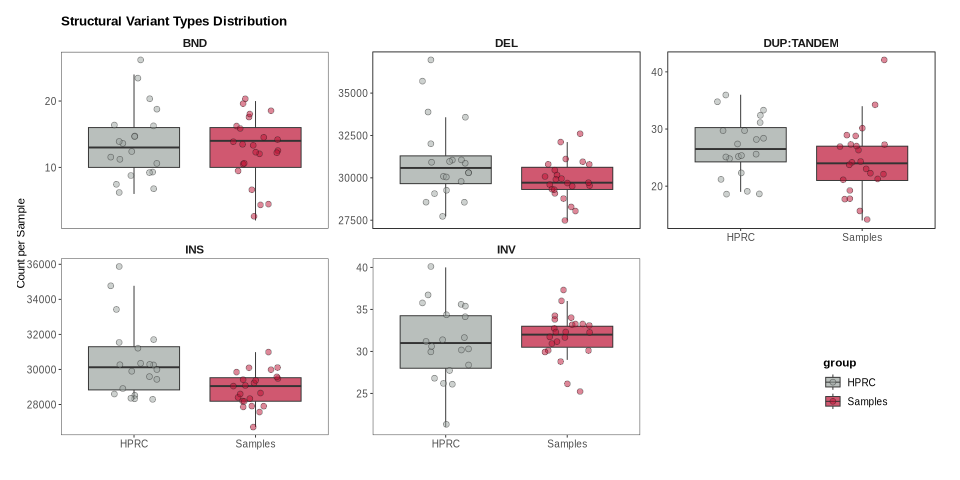

In [14]:
# Figure: SV Type Distribution by Sample
sv_type_counts <- sv_details %>%
    group_by(sample, group, sv_type) %>%
    summarise(count = n(), .groups = "drop")

fig_sv_type <- ggplot(sv_type_counts, aes(x = group, y = count, fill = group)) +
    geom_boxplot(alpha = 0.7, outlier.shape = NA) +
    geom_jitter(aes(fill = group), shape=21, colour="grey10", width = 0.2, alpha = 0.5, size = 1.5) +
    scale_fill_manual(values = col_source) +
    facet_wrap(~sv_type, nrow = 2, scales = "free_y", ) +
    labs(
        title = "Structural Variant Types Distribution",
        x = "",
        y = "Count per Sample"
    ) +
    theme(
        #axis.text.x = element_blank(),
        legend.position = c(0.95, 0.05),
        legend.justification = c("right", "bottom"),
        legend.direction = "vertical"
    )

fig_sv_type
ggsave(file.path(var_fig_dir, "sv_type_distribution.png"), fig_sv_type, width = 5, height = 4, dpi = 300)
ggsave(file.path(var_fig_dir, "sv_type_distribution.pdf"), fig_sv_type, width = 5, height = 4, dpi = 300)


Warning message in scale_y_log10(labels = scales::comma):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(labels = scales::comma):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 1915 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1915 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in scale_y_log10(labels = scales::comma):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(labels = scales::comma):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 1915 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1915 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in scale_y_log10(labels = scales::comma):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(lab

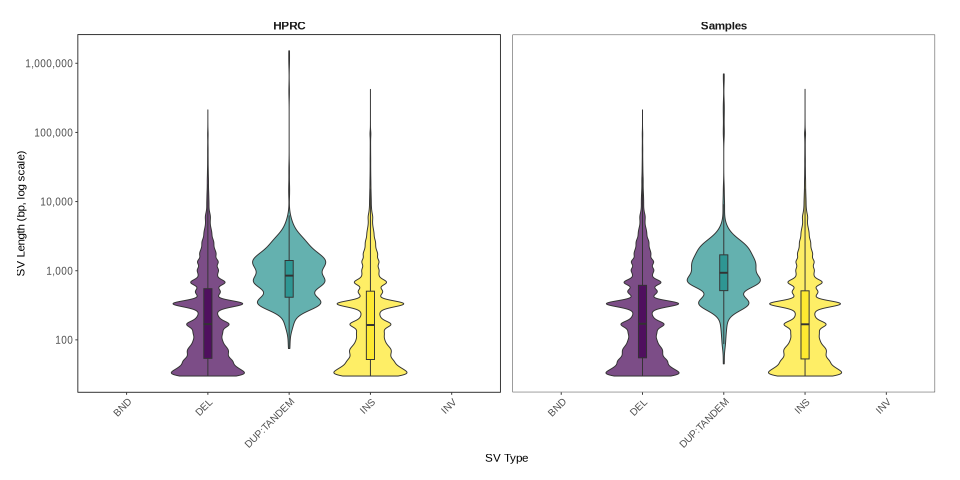

In [15]:
# Figure: SV Size Distribution (log scale)
fig_sv_size <- ggplot(sv_details, aes(x = sv_type, y = sv_len, fill = sv_type)) +
    geom_violin(alpha = 0.7, scale = "width") +
    geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
    scale_y_log10(labels = scales::comma) +
    scale_fill_viridis_d(option = "D", guide = "none") +
    facet_wrap(~group, nrow = 1) +
    labs(
        x = "SV Type",
        y = "SV Length (bp, log scale)"
    ) +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1)
    )

fig_sv_size
ggsave(file.path(var_fig_dir, "sv_size_distribution.png"), fig_sv_size, width = 3.5, height = 2.2, dpi = 300)
ggsave(file.path(var_fig_dir, "sv_size_distribution.pdf"), fig_sv_size, width = 3.5, height = 2.2, dpi = 300)


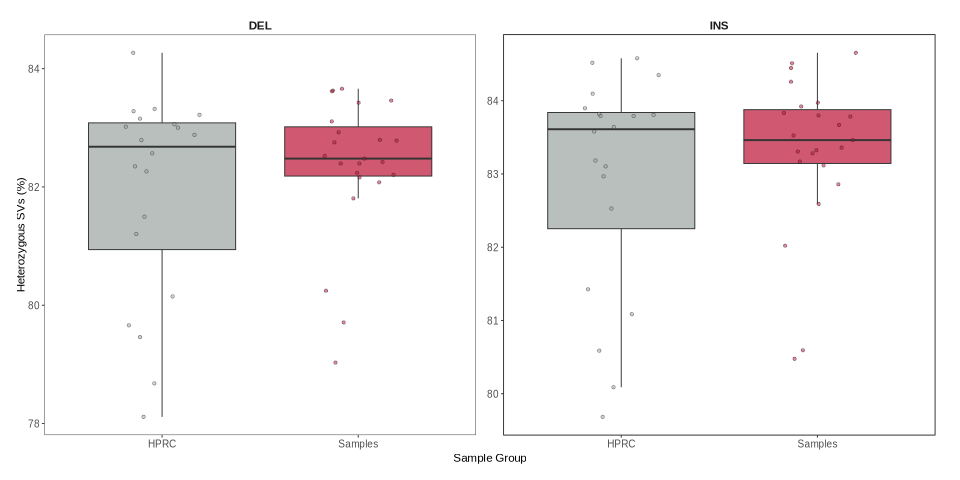

In [16]:
# Figure: SV Zygosity Distribution
sv_zygosity <- sv_details %>%
    group_by(sample, group, sv_type, zygosity) %>%
    summarise(count = n(), .groups = "drop") %>%
    group_by(sample, group, sv_type) %>%
    mutate(percentage = count / sum(count) * 100) %>%
    filter(sv_type %in% c("DEL", "INS")) %>%
    filter(zygosity %in% c("HET"))


fig_sv_zygosity <- ggplot(sv_zygosity, aes(x = group, y = percentage, fill = group)) +
    geom_boxplot(alpha = 0.7, outliers = FALSE) +
    geom_jitter(width = 0.2, alpha = 0.5, shape = 21, colour = "grey10") +
    scale_fill_manual(values = col_source) +
    scale_color_manual(values = col_source, guide = "none") +
    facet_wrap(~sv_type, scales = "free") + 
    labs(
        x = "Sample Group",
        y = "Heterozygous SVs (%)"
    ) +
    theme(legend.position = "none")

fig_sv_zygosity
ggsave(file.path(var_fig_dir, "sv_zygosity_type.png"), fig_sv_zygosity, width = 3.5, height = 2.2, dpi = 300)
ggsave(file.path(var_fig_dir, "sv_zygosity_type.pdf"), fig_sv_zygosity, width = 3.5, height = 2.2, dpi = 300)


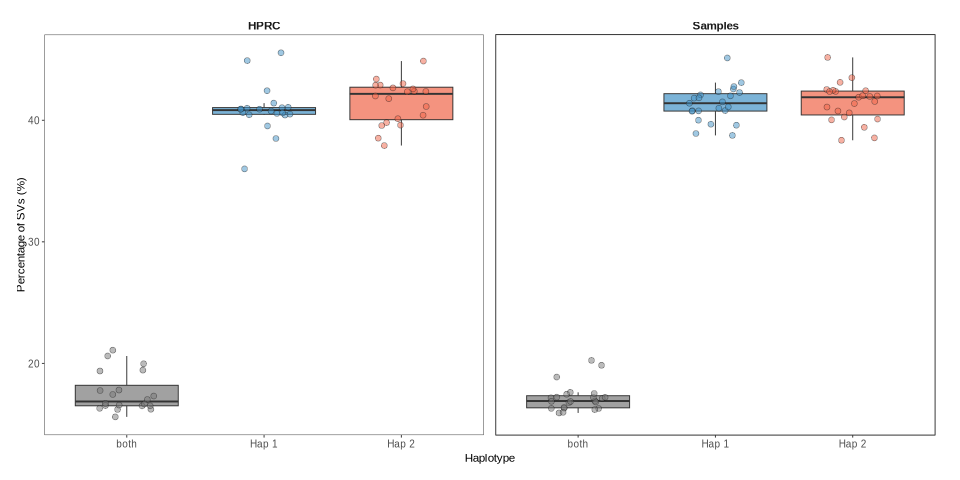

In [17]:
# Figure: SV Haplotype Distribution (phasing quality indicator)
sv_haplotype <- sv_details %>%
    group_by(sample, group, haplotype) %>%
    summarise(count = n(), .groups = "drop") %>%
    group_by(sample, group) %>%
    mutate(percentage = count / sum(count) * 100)

    sv_haplotype <- sv_haplotype %>%
        mutate(haplotype = recode(haplotype, 
        "haplotype1" = "Hap 1", "haplotype2" = "Hap 2"))

fig_sv_haplotype <- ggplot(sv_haplotype, aes(x = haplotype, y = percentage, fill = haplotype)) +
    geom_boxplot(alpha = 0.7, outliers = FALSE) +
    geom_jitter(aes(fill = haplotype), width = 0.2, alpha = 0.5, size = 1.5, shape = 21, colour = "grey10") +
    scale_fill_manual(values = col_haplotype) +
    facet_wrap(~group) + 
    labs(
        x = "Haplotype",
        y = "Percentage of SVs (%)"
    ) +
    theme(
        legend.position = "none"
    )

fig_sv_haplotype
ggsave(file.path(var_fig_dir, "sv_haplotype_distribution.png"), fig_sv_haplotype, width = 3.5, height = 2.2, dpi = 300)
ggsave(file.path(var_fig_dir, "sv_haplotype_distribution.pdf"), fig_sv_haplotype, width = 3.5, height = 2.2, dpi = 300)


`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by sample, group, and chrom.
ℹ Output is grouped by sample and group.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(sample, group, chrom))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


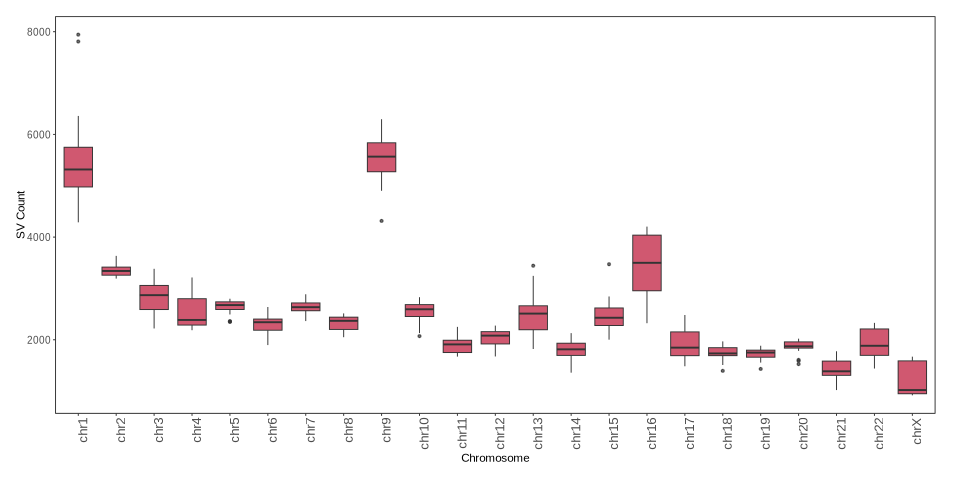

In [18]:
# Figure: SV Counts per Chromosome
sv_per_chrom <- sv_details %>%
    filter(!chrom %in% c("chrM", "chrY")) %>%  # Exclude chrM and optionally chrY
    filter(group == "Samples") %>%
    mutate(chrom = factor(chrom, levels = paste0("chr", c(1:22, "X")))) %>%
    group_by(sample, group, chrom) %>%
    summarise(count = n()) %>%
    ungroup()

fig_sv_per_chrom <- ggplot(sv_per_chrom, aes(x = chrom, y = count, fill = group)) +
    geom_boxplot(alpha = 0.7, outlier.size = 0.5) +
    scale_fill_manual(values = col_source) +
    labs(
        x = "Chromosome",
        y = "SV Count"
    ) +
    theme(
        axis.text.x = element_text(angle = 90, hjust = 1, size = 8),
        legend.position = "none"
    )

fig_sv_per_chrom
ggsave(file.path(var_fig_dir, "sv_per_chromosome.png"), fig_sv_per_chrom, width = 3.5, height = 2.2, dpi = 300)
ggsave(file.path(var_fig_dir, "sv_per_chromosome.pdf"), fig_sv_per_chrom, width = 3.5, height = 2.2, dpi = 300)


`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by sample, group, haplotype, and chrom.
ℹ Output is grouped by sample, group, and haplotype.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(sample, group, haplotype, chrom))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


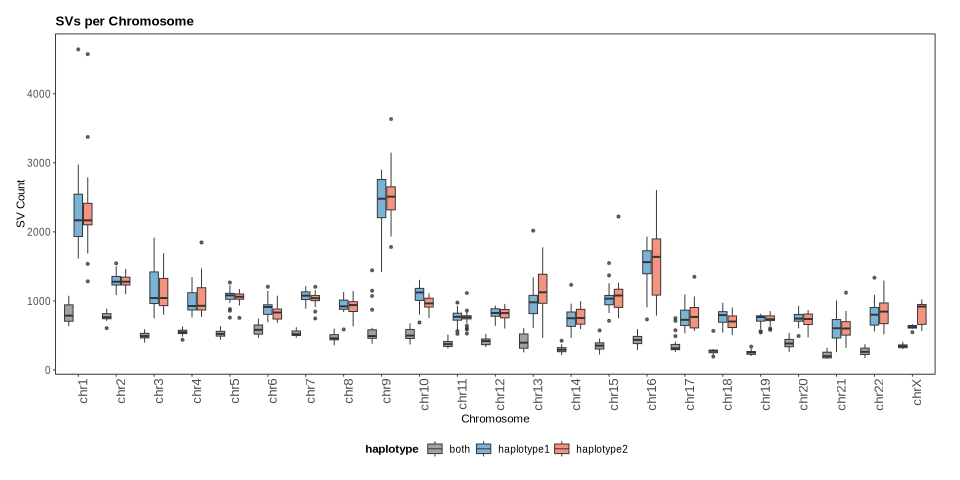

In [19]:
# Figure: SV Counts per Chromosome
sv_per_chrom_and_hap <- sv_details %>%
    filter(!chrom %in% c("chrM", "chrY")) %>%  # Exclude chrM and optionally chrY
    filter(group == "Samples") %>%
    mutate(chrom = factor(chrom, levels = paste0("chr", c(1:22, "X")))) %>%
    group_by(sample, group, haplotype, chrom) %>%
    summarise(count = n()) %>%
    ungroup()

fig_sv_per_chrom_and_hap <- ggplot(sv_per_chrom_and_hap, aes(x = chrom, y = count, fill = haplotype)) +
    geom_boxplot(alpha = 0.7, outlier.size = 0.5) +
    scale_fill_manual(values = col_haplotype) +
    labs(
        title = "SVs per Chromosome",
        x = "Chromosome",
        y = "SV Count"
    ) +
    theme(
        axis.text.x = element_text(angle = 90, hjust = 1, size = 8),
        legend.position = "bottom"
    )

fig_sv_per_chrom_and_hap
ggsave(file.path(var_fig_dir, "sv_per_chromosome_and_haplotype.png"), fig_sv_per_chrom_and_hap, width = 5, height = 2.2, dpi = 300)
ggsave(file.path(var_fig_dir, "sv_per_chromosome_and_haplotype.pdf"), fig_sv_per_chrom_and_hap, width = 5, height = 2.2, dpi = 300)


### chr9 SV localisation — pericentromeric heterochromatin

Does the elevated chr9 SV count reflect calls concentrated in the 9q pericentromeric heterochromatic block (9q12), as the reviewer suggests? We bin SVs in 2 Mb windows and annotate against the CHM13v2.0 CenSat annotation (covers 40–81.7 Mb on chr9, i.e. p-arm transition → centromere → q-arm heterochromatin → q-arm transition).

# A tibble: 3 × 3
  region                                 mean_n   pct
  <chr>                                   <dbl> <dbl>
1 9p arm                                   348.  6.26
2 9q arm                                   767. 13.8 
3 Pericentromeric heterochromatin (9q12)  4433. 79.9 


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Shaded: pericentromeric heterochromatin (CenSat annotation, 40–81.7 Mb)' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”


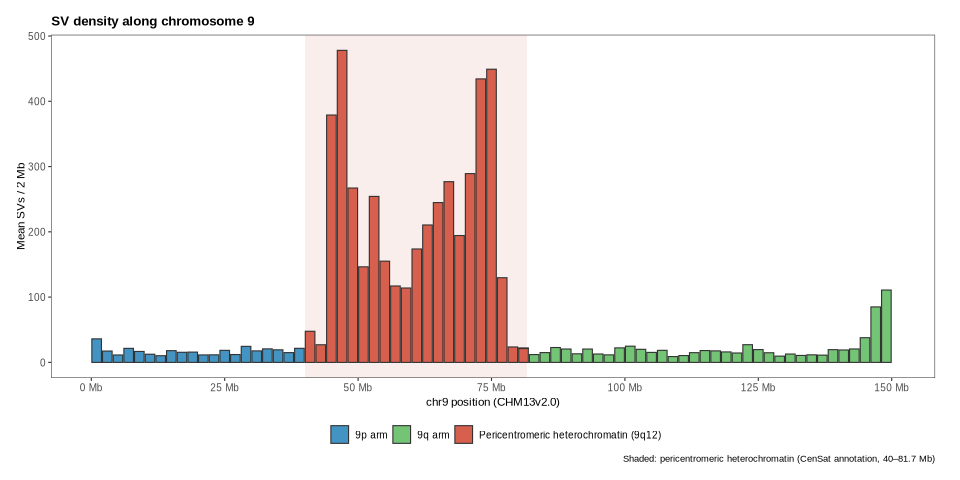

In [ ]:
# ── chr9 SV density: confirm pericentromeric localisation ─────────────────────
CENSAT_START <- 40.0e6   # CenSat annotation start on CHM13 chr9 (Mb)
CENSAT_END   <- 81.7e6   # CenSat annotation end
CHR9_LEN     <- 150.6e6  # CHM13 chr9 total length
BIN_SIZE     <-  2.0e6   # 2 Mb bins

chr9_svs <- sv_details |>
  filter(chrom == "chr9", group == "Samples") |>
  mutate(
    bin_start = floor(pos / BIN_SIZE) * BIN_SIZE,
    region    = case_when(
      pos >= CENSAT_START & pos <= CENSAT_END ~ "Pericentromeric heterochromatin (9q12)",
      pos  < CENSAT_START                     ~ "9p arm",
      TRUE                                    ~ "9q arm"
    )
  )

# Mean SV count per 2 Mb bin across samples
chr9_density <- chr9_svs |>
  count(sample, bin_start, region) |>
  group_by(bin_start, region) |>
  summarise(mean_count = mean(n), .groups = "drop") |>
  mutate(bin_mid = (bin_start + BIN_SIZE / 2) / 1e6)

# Fraction of chr9 SVs in pericentromeric region
pct_peri <- chr9_svs |>
  count(sample, region) |>
  group_by(region) |>
  summarise(mean_n = mean(n), .groups = "drop") |>
  mutate(pct = mean_n / sum(mean_n) * 100)
print(pct_peri)

region_cols <- c(
  "9p arm"                                   = "#4393C3",
  "Pericentromeric heterochromatin (9q12)"   = "#D6604D",
  "9q arm"                                   = "#74C476"
)

p_chr9_sv <- ggplot(chr9_density,
                    aes(x = bin_mid, y = mean_count, fill = region)) +
  annotate("rect",
    xmin = CENSAT_START / 1e6, xmax = CENSAT_END / 1e6,
    ymin = -Inf, ymax = Inf,
    alpha = 0.1, fill = "#D6604D") +
  geom_col(width = BIN_SIZE / 1e6 * 0.9, color = "grey20") +
  scale_fill_manual(values = region_cols, name = NULL) +
  scale_x_continuous(
    labels = \(x) paste0(x, " Mb"),
    breaks = seq(0, 150, 25),
    limits = c(0, CHR9_LEN / 1e6)
  ) +
  labs(
    x       = "chr9 position (CHM13v2.0)",
    y       = "Mean SVs / 2 Mb",
    title   = "SV density along chromosome 9, all samples",
    caption = "Shaded: pericentromeric heterochromatin (CenSat annotation, 40–81.7 Mb)"
  ) +
  t2t_theme(base_size = 7) +
  theme(legend.position = "bottom")

ggsave("../../doc/figures/chr9_sv_density.pdf", p_chr9_sv, width = 6, height = 3)
ggsave("../../doc/figures/chr9_sv_density.png", p_chr9_sv, width = 6, height = 3, dpi = 300)
p_chr9_sv


## Small Variant Analysis

Analysis of small variants (SNVs, indels) from dipcall including:
- Variant type distribution (SNV, INS, DEL, MNV)
- Transition/Transversion ratio
- Zygosity and phasing statistics
- Indel size distribution

In [21]:
# Load small variant statistics (combining all_samples and HPRC)
small_var_summary_t2t <- read_tsv("../../doc/tables/for_plots/small_variant_stats_summary.all_samples.tsv", show_col_types = FALSE)
small_var_summary_hprc <- read_tsv("../../doc/tables/for_plots/small_variant_stats_summary.hprc.tsv", show_col_types = FALSE)

# Combine datasets
small_var_summary <- bind_rows(
    small_var_summary_t2t %>% mutate(dataset = "Samples"),
    small_var_summary_hprc %>% mutate(dataset = "HPRC")
)

# Check data
head(small_var_summary)
cat("\nCategories available:", unique(small_var_summary$category))
cat("\nGroups:", unique(small_var_summary$group))


sample,category,subcategory,var_type,count,percentage,dataset
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
T2T00,allelic,biallelic,DEL,452461,76.24364,Samples
T2T00,allelic,multiallelic,DEL,140980,23.75636,Samples
T2T00,allelic,biallelic,INS,407412,80.94476,Samples
T2T00,allelic,multiallelic,INS,95909,19.05524,Samples
T2T00,allelic,multiallelic,MNV,2164,100.00000,Samples
T2T00,allelic,biallelic,SNV,4092058,96.53184,Samples



Categories available: allelic chromosome filter haplotype indel_size phasing ti_tv total variant_type zygosity

Warning message:
“Unknown or uninitialised column: `group`.”



Groups:

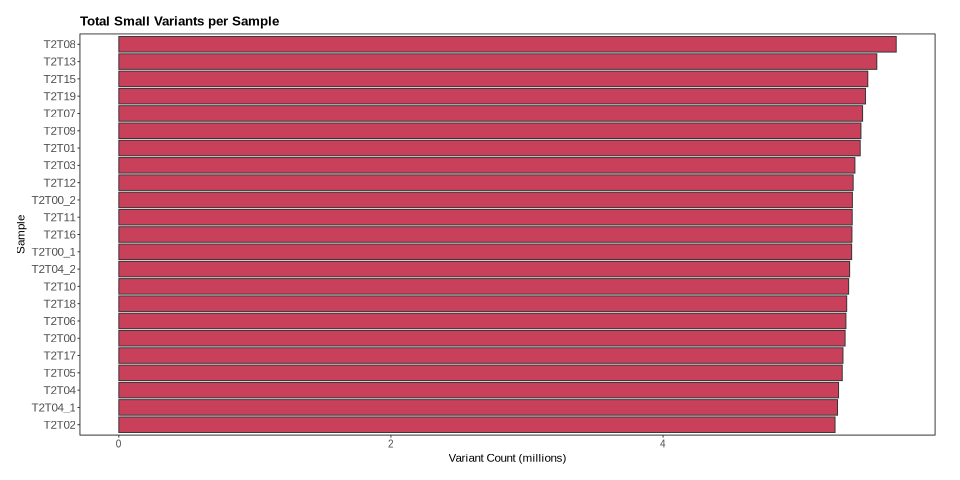

In [22]:
# Figure: Total Variant Count per Sample
total_variants_samples <- small_var_summary %>%
    filter(category == "total", subcategory == "all_variants") %>%
    filter(dataset == "Samples")

fig_total_variants <- ggplot(total_variants_samples, aes(x = reorder(sample, count), y = count/1e6, fill = dataset)) +
    geom_bar(stat = "identity", alpha = 0.8, col = "grey20") +
    coord_flip() +
    scale_fill_manual(values = col_source, name = "Sample Group") +
    labs(
        title = "Total Small Variants per Sample",
        x = "Sample",
        y = "Variant Count (millions)"
    ) +
    theme(
        axis.text.y = element_text(size = 7),
        legend.position = "none"
    )

fig_total_variants
ggsave(file.path(var_fig_dir, "small_var_total_per_sample.png"), fig_total_variants, width = 3.5, height = 2.2, dpi = 300)
ggsave(file.path(var_fig_dir, "small_var_total_per_sample.pdf"), fig_total_variants, width = 3.5, height = 2.2, dpi = 300)

Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”
Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”
Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”
Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”
Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”
Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”


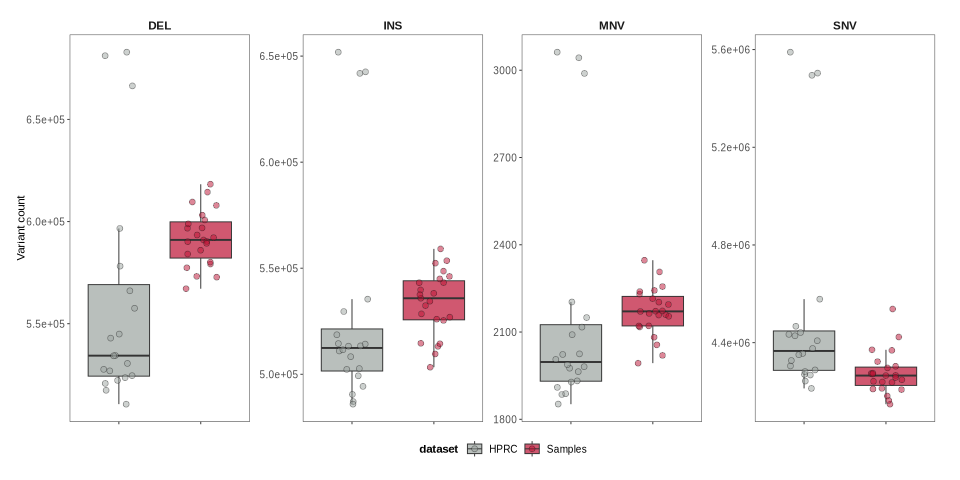

In [23]:
# Figure: Variant Type Distribution
var_type_data <- small_var_summary %>%
    filter(category == "variant_type")

fig_var_type <- ggplot(var_type_data, aes(x = dataset, y = count, fill = dataset)) +
    geom_boxplot(alpha = 0.7, outliers = FALSE) +
    geom_jitter(width = 0.2, alpha = 0.5, size = 1.5, shape = 21, col = "grey10") +
    scale_fill_manual(values = col_source) +
    scale_color_manual(values = col_source, guide = "none") +
    facet_wrap(~subcategory, nrow = 1, scales = "free") +
    labs(
        title = element_blank(),
        x = element_blank(),
        y = "Variant count"
    ) +
    scale_y_continuous(labels = function(x) ifelse(x >= 10000, scales::scientific_format()(x), x)) +
    theme(
        axis.text.x = element_blank(),
        legend.position = "bottom"
    )

fig_var_type
ggsave(file.path(var_fig_dir, "small_var_type_distribution.png"), fig_var_type, width = 3.5, height = 2.2, dpi = 300)
ggsave(file.path(var_fig_dir, "small_var_type_distribution.pdf"), fig_var_type, width = 3.5, height = 2.2, dpi = 300)

Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”
Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”
Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”


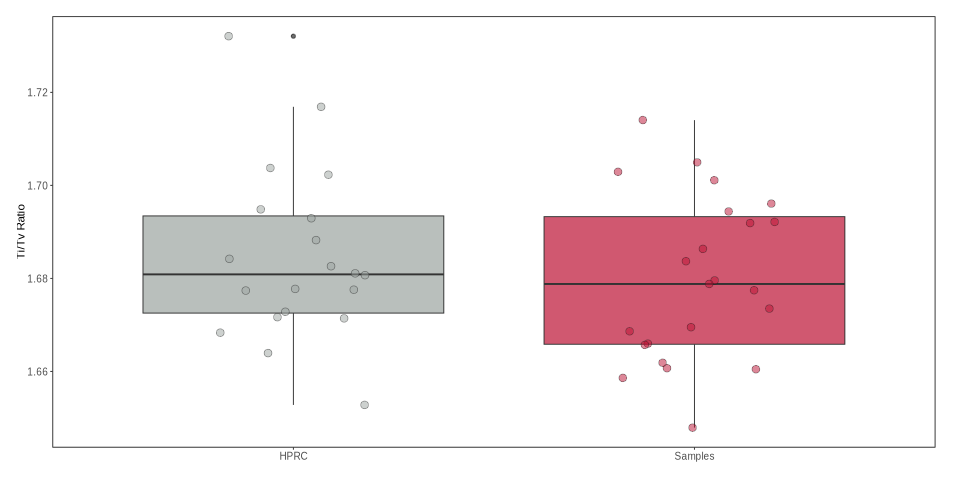

In [24]:
# Figure: Ti/Tv Ratio
ti_tv_data <- small_var_summary %>%
    filter(category == "ti_tv", subcategory == "transitions") %>%
    rename(ti_tv_ratio = percentage)  # percentage column stores the ratio

fig_ti_tv <- ggplot(ti_tv_data, aes(x = dataset, y = ti_tv_ratio, fill = dataset)) +
    geom_boxplot(alpha = 0.7) +
    geom_jitter(width = 0.2, alpha = 0.5, size = 2, shape = 21, colour = "grey10") +
    scale_fill_manual(values = col_source, guide = "none") +
    labs(
        x = element_blank(),
        y = "Ti/Tv Ratio"
    )

fig_ti_tv
ggsave(file.path(var_fig_dir, "small_var_ti_tv_ratio.png"), fig_ti_tv, width = 2, height = 2.2, dpi = 300)
ggsave(file.path(var_fig_dir, "small_var_ti_tv_ratio.pdf"), fig_ti_tv, width = 2, height = 2.2, dpi = 300)

Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”


Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”
Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”


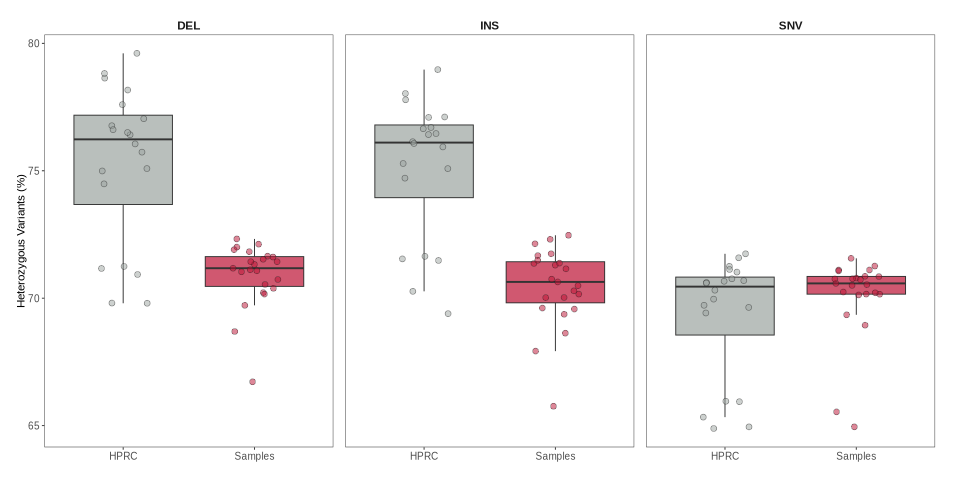

In [25]:
# Figure: Zygosity Distribution by Variant Type (SNV, DEL, INS)
zygosity_by_type <- small_var_summary %>%
    filter(category == "zygosity", var_type %in% c("SNV", "DEL", "INS")) %>%
    filter(subcategory == "HET")

fig_zygosity_by_type <- ggplot(zygosity_by_type, aes(x = dataset, y = percentage, fill = dataset)) +
    geom_boxplot(alpha = 0.7, outliers = FALSE) +
    geom_jitter(aes(color = dataset), width = 0.2, shape = 21, colour = "grey10", alpha = 0.5, size = 1.5) +
    facet_wrap(~var_type) +
    scale_fill_manual(values = col_source) +
    scale_color_manual(values = col_source, guide = "none") +
    labs(
        x = element_blank(),
        y = "Heterozygous Variants (%)"
    ) +
    theme(legend.position = "none")

fig_zygosity_by_type
ggsave(file.path(var_fig_dir, "small_var_zygosity_by_type.png"), fig_zygosity_by_type, width =3.5, height = 2.2, dpi = 300)
ggsave(file.path(var_fig_dir, "small_var_zygosity_by_type.pdf"), fig_zygosity_by_type, width =3.5, height = 2.2, dpi = 300)


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


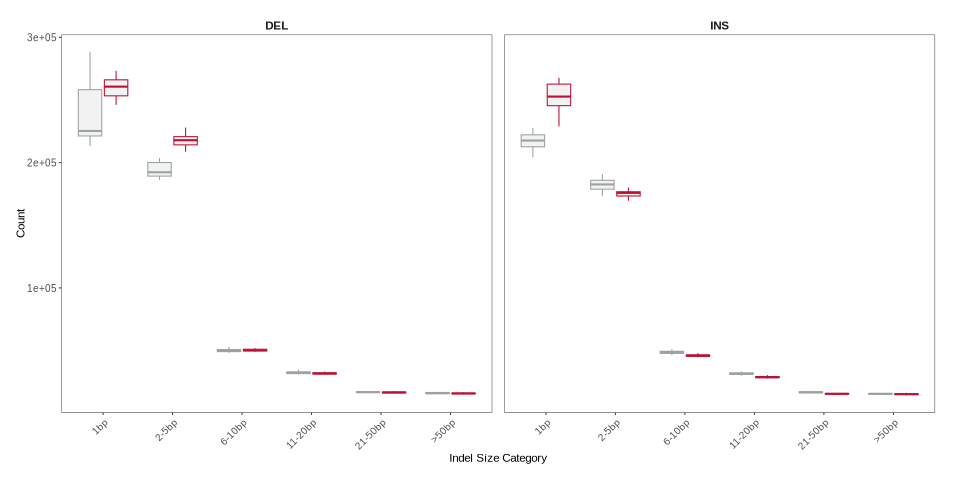

In [26]:
# Figure: Indel Size Distribution by Variant Type (DEL vs INS)
indel_size_by_type <- small_var_summary %>%
    filter(category == "indel_size", var_type %in% c("DEL", "INS")) %>%
    mutate(subcategory = factor(subcategory, 
                                levels = c("1bp", "2-5bp", "6-10bp", "11-20bp", "21-50bp", ">50bp")))

fig_indel_size_by_type <- ggplot(indel_size_by_type, aes(x = subcategory, y = count, col = dataset)) +
    geom_boxplot(alpha = 1, outlier.shape = NA, linewidth = 0.3, fill = "grey95") +
    #geom_jitter(aes(color = group), width = 0.2, alpha = 0.5, size = 1.5) +
    facet_wrap(~var_type) +
    scale_fill_manual(values = col_source) +
    scale_color_manual(values = col_source, guide = "none") +
    labs(
        x = "Indel Size Category",
        y = "Count"
    ) +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom"
    )

fig_indel_size_by_type
ggsave(file.path(var_fig_dir, "small_var_indel_size_by_type.png"), fig_indel_size_by_type, width = 4, height = 2.2, dpi = 300)
ggsave(file.path(var_fig_dir, "small_var_indel_size_by_type.pdf"), fig_indel_size_by_type, width = 4, height = 2.2, dpi = 300)

## Combined Variant Summary

Overall comparison of variant metrics across samples.

In [27]:
# Create a combined summary table for key metrics
# SV summary by type
sv_summary_table <- sv_summary %>%
    filter(category == "sv_type") %>%
    select(sample, subcategory, count) %>%
    pivot_wider(names_from = subcategory, values_from = count, values_fill = 0) %>%
    mutate(variant_class = "SV")

# Small variant summary by type
small_var_type_summary <- small_var_summary %>%
    filter(category == "variant_type") %>%
    select(sample, subcategory, count) %>%
    pivot_wider(names_from = subcategory, values_from = count, values_fill = 0) %>%
    mutate(variant_class = "Small")

# Combine and display
combined_summary <- bind_rows(
    sv_summary_table %>% select(sample, variant_class, everything()),
    small_var_type_summary %>% select(sample, variant_class, everything())
)

# Add group info
combined_summary <- combined_summary %>%
    mutate(
        group = case_when(
            grepl("^T2T", sample) ~ "T2T Samples",
            grepl("^HG", sample) ~ "Reference",
            TRUE ~ "Other"
        )
    )

head(combined_summary, 10)

sample,variant_class,BND,DEL,DUP:TANDEM,INS,INV,MNV,SNV,group
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
T2T00,SV,16,30800,21,29846,30,NA,NA,T2T Samples
T2T00_1,SV,14,30079,27,29050,30,NA,NA,T2T Samples
T2T00_2,SV,4,29504,14,28653,33,NA,NA,T2T Samples
T2T01,SV,10,29081,19,27860,34,NA,NA,T2T Samples
T2T02,SV,12,28284,23,27567,34,NA,NA,T2T Samples
T2T03,SV,12,29536,27,29480,32,NA,NA,T2T Samples
T2T04,SV,20,30163,24,29083,31,NA,NA,T2T Samples
T2T04_1,SV,2,31110,24,29230,32,NA,NA,T2T Samples
T2T04_2,SV,14,28040,22,27902,33,NA,NA,T2T Samples


Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”
Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”
Warning message:
“`label` cannot be a <ggplot2::element_blank> object.”


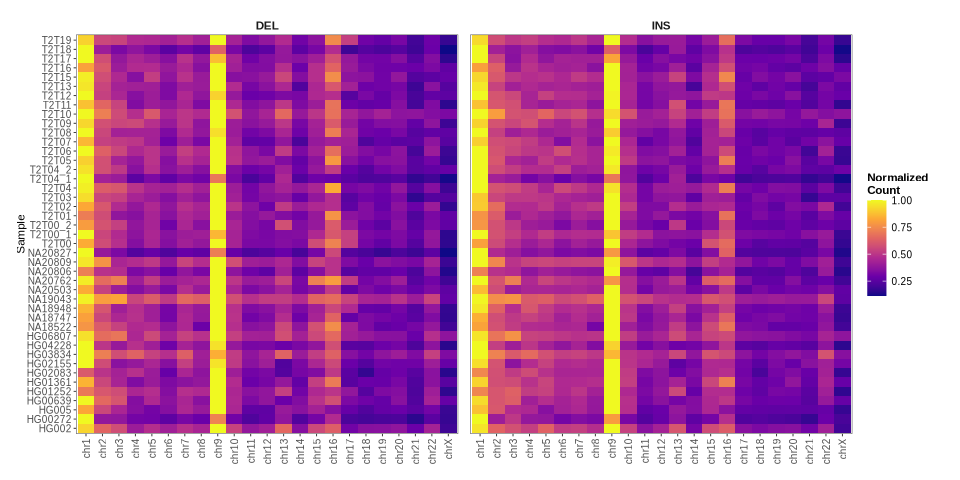

In [28]:
# Figure: Heatmap of variant types per chromosome (SVs)
sv_chrom_heatmap_data <- sv_details %>%
    filter(!chrom %in% c("chrM", "chrY")) %>%
    mutate(chrom = factor(chrom, levels = paste0("chr", c(1:22, "X")))) %>%
    group_by(sample, chrom, sv_type) %>%
    summarise(count = n(), .groups = "drop") %>%
    group_by(sample, sv_type) %>%
    mutate(normalized_count = count / max(count))  # Normalize per sample/type

fig_sv_heatmap <- ggplot(sv_chrom_heatmap_data %>% filter(sv_type %in% c("DEL", "INS")), 
                         aes(x = chrom, y = sample, fill = normalized_count)) +
    geom_tile() +
    facet_wrap(~sv_type) +
    scale_fill_viridis_c(option = "plasma", name = "Normalized\nCount") +
    labs(
        x = element_blank(),
        y = "Sample"
    ) +
    theme(
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
        axis.text.y = element_text(size = 6)
    )

fig_sv_heatmap
ggsave(file.path(var_fig_dir, "sv_chromosome_heatmap.png"), fig_sv_heatmap, width = 7, height = 3.5, dpi = 300)
ggsave(file.path(var_fig_dir, "sv_chromosome_heatmap.pdf"), fig_sv_heatmap, width = 7, height = 3.5, dpi = 300)
